In [ ]:
# ==========================================
# 1: SETUP & MODEL LOADING
# ==========================================
!pip install open_clip_torch peft > /dev/null

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             roc_curve, recall_score, f1_score, balanced_accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip
from PIL import Image
from peft import LoraConfig, get_peft_model, PeftModel

# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir  = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"

train_df = pd.read_csv(base_path + "/train_split.csv")
val_df   = pd.read_csv(base_path + "/val_split.csv")
test_df  = pd.read_csv(base_path + "/test_split.csv")

# Load Base BioMedCLIP
print("Loading Base BioMedCLIP...")
model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
clip_model, _, preprocess = open_clip.create_model_and_transforms(model_name)
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer(model_name)
print("Loaded successfully!")

# ==========================================
#  2: DATASET & AUGMENTATIONS
# ==========================================
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
])

class HybridMRNetDataset(Dataset):
    def __init__(self, df, plane_dir, is_train=False):
        self.df = df
        self.plane_dir = plane_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]

        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))
        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

        processed_slices = []
        for i in range(vol.shape[0]):
            slice_img = cv2.resize(vol[i], (224, 224))
            slice_img = (slice_img * 255).astype(np.uint8)
            slice_rgb = np.stack((slice_img,)*3, axis=-1)

            if self.is_train:
                slice_rgb = np.array(train_transform(slice_rgb))

            img_pil = Image.fromarray(slice_rgb)
            img_tensor = preprocess(img_pil)
            processed_slices.append(img_tensor)

        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.long), patient_id

# Sampler for Class Imbalance
labels = train_df["label"].values
class_counts = np.bincount(labels)
sample_weights = (1. / class_counts)[labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
#  3: HYBRID ARCHITECTURE (CO-OP + LoRA + ATTN)
# ==========================================
class CoOpPromptLearner(nn.Module):
    def __init__(self, clip_model, tokenizer, n_ctx=16):
        super().__init__()
        self.n_ctx = n_ctx
        self.word_embeddings = clip_model.text.transformer.embeddings.word_embeddings
        embed_dim = self.word_embeddings.embedding_dim

        ctx_vectors = torch.empty(n_ctx, embed_dim)
        nn.init.normal_(ctx_vectors, std=0.02)
        self.ctx = nn.Parameter(ctx_vectors)

        classnames = ["intact normal anterior cruciate ligament", "complete tear of the anterior cruciate ligament"]
        tokenized_classes = tokenizer(classnames).to(device)
        self.tokenized_classes = tokenized_classes

        with torch.no_grad():
            class_embeddings = self.word_embeddings(tokenized_classes)

        self.register_buffer("token_prefix", class_embeddings[:, :1, :])
        self.register_buffer("token_suffix", class_embeddings[:, 1 : 256 - n_ctx, :])

    def forward(self):
        ctx = self.ctx.unsqueeze(0).expand(2, -1, -1)
        return torch.cat([self.token_prefix, ctx, self.token_suffix], dim=1)

class GatedAttention(nn.Module):
    def __init__(self, embed_dim=512, hidden_dim=256):
        super().__init__()
        self.attention_V = nn.Linear(embed_dim, hidden_dim)
        self.attention_U = nn.Linear(embed_dim, hidden_dim)
        self.attention_weights = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        a_v = torch.tanh(self.attention_V(x))
        a_u = torch.sigmoid(self.attention_U(x))
        w = self.attention_weights(a_v * a_u)
        A = torch.softmax(w, dim=0)
        M = torch.sum(A * x, dim=0, keepdim=True)
        return M, A

class HybridBioMedCLIP(nn.Module):
    def __init__(self, clip_model, tokenizer, n_ctx=16):
        super().__init__()
        self.clip_model = clip_model
        self.prompt_learner = CoOpPromptLearner(clip_model, tokenizer, n_ctx)

        lora_config = LoraConfig(
            r=16, lora_alpha=32,
            target_modules=["fc1", "fc2", "c_fc", "c_proj", "out_proj", "proj"],
            lora_dropout=0.1, bias="none"
        )
        self.vision_encoder = get_peft_model(clip_model.visual, lora_config)
        self.attention = GatedAttention(embed_dim=512, hidden_dim=256)

        for param in self.clip_model.text.parameters():
            param.requires_grad = False

    def forward(self, image_volume):
        prompts_embeds = self.prompt_learner()
        attention_mask = torch.ones((2, 256), device=device)
        text_outputs = self.clip_model.text.transformer(inputs_embeds=prompts_embeds, attention_mask=attention_mask)
        text_features = self.clip_model.text.proj(text_outputs.last_hidden_state[:, 0, :])
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        image_features = self.vision_encoder(image_volume)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        patient_img_feat, attn_weights = self.attention(image_features)
        patient_img_feat = patient_img_feat / patient_img_feat.norm(dim=-1, keepdim=True)

        logits = self.clip_model.logit_scale.exp() * patient_img_feat @ text_features.t()
        return logits, attn_weights

# ==========================================
# 4: HYBRID TRAINING LOOP (with AMP)
# ==========================================
def train_hybrid_model(planes, epochs=10):
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    for plane_name, plane_dir in planes:
        print(f"\n{'='*50}\n STARTING HYBRID LoRA + CO-OP + ATTN ({plane_name.upper()})\n{'='*50}")

        train_ds = HybridMRNetDataset(train_df, plane_dir, is_train=True)
        val_ds   = HybridMRNetDataset(val_df, plane_dir, is_train=False)

        train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler, num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

        model = HybridBioMedCLIP(clip_model, tokenizer).to(device)

        # LOAD PRE-TRAINED CO-OP WEIGHTS
        coop_path = os.path.join(base_path, f"coop_{plane_name}_best_prompts.pth")
        model.prompt_learner.load_state_dict(torch.load(coop_path))
        print("  => Pre-trained Co-Op weights loaded successfully.")

        # FREEZE CO-OP WEIGHTS INITIALLY
        for param in model.prompt_learner.parameters():
            param.requires_grad = False

        trainable_params = list(filter(lambda p: p.requires_grad, model.vision_encoder.parameters())) + \
                           list(model.attention.parameters())

        optimizer = optim.AdamW(trainable_params, lr=2e-4, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

        best_auc = 0.0

        for epoch in range(epochs):
            # STAGED TRAINING: UNFREEZE CO-OP FOR THE LAST 5 EPOCHS
            if epoch == 5:
                for param in model.prompt_learner.parameters():
                    param.requires_grad = True
                optimizer.add_param_group({'params': model.prompt_learner.parameters(), 'lr': 1e-5})
                print("  => Co-Op weights unfrozen for final fine-tuning.")

            model.train()
            t_loss, t_correct, t_total = 0, 0, 0

            for imgs, lbls, _ in train_loader:
                imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)
                optimizer.zero_grad()

                with autocast('cuda'):
                    logits, _ = model(imgs)
                    loss = criterion(logits, lbls)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                t_loss += loss.item()
                preds = logits.argmax(dim=1)
                t_correct += (preds == lbls).sum().item()
                t_total += 1

            scheduler.step()

            model.eval()
            v_loss, v_correct, v_total, y_true, y_probs = 0, 0, 0, [], []
            with torch.no_grad():
                for imgs, lbls, _ in val_loader:
                    imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)

                    with autocast('cuda'):
                        logits, _ = model(imgs)
                        v_loss += criterion(logits, lbls).item()

                    prob_tear = logits.softmax(dim=-1)[0, 1].item()
                    y_true.append(lbls.item())
                    y_probs.append(prob_tear)

                    if logits.argmax(dim=1).item() == lbls.item(): v_correct += 1
                    v_total += 1

            auc = roc_auc_score(y_true, y_probs)

            print(f"Epoch [{epoch+1}/{epochs}] | LR: {scheduler.get_last_lr()[0]:.2e}")
            print(f"  [Train] Loss: {t_loss/t_total:.4f} | Acc: {(t_correct/t_total)*100:.2f}%")
            print(f"  [Val]   Loss: {v_loss/v_total:.4f} | Acc: {(v_correct/v_total)*100:.2f}% | AUC: {auc:.4f}")
            print("-" * 45)

            if auc > best_auc:
                best_auc = auc
                torch.save(model.state_dict(), os.path.join(base_path, f"hybrid_{plane_name}_best.pth"))
                print("  => New Best Models Saved!")

        clip_model.visual = model.vision_encoder.unload()


Mounted at /content/drive
Using device: cuda
Loading Base BioMedCLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded successfully!


In [ ]:
target_planes = [("sagittal", sagittal_dir)]
train_hybrid_model(target_planes, epochs=10)


 STARTING HYBRID LoRA + CO-OP + ATTN (SAGITTAL)
  => Pre-trained Co-Op weights loaded successfully.
Epoch [1/10] | LR: 1.95e-04
  [Train] Loss: 0.8749 | Acc: 54.29%
  [Val]   Loss: 0.5022 | Acc: 77.60% | AUC: 0.7706
---------------------------------------------
  => New Best Models Saved!
Epoch [2/10] | LR: 1.81e-04
  [Train] Loss: 0.6411 | Acc: 66.29%
  [Val]   Loss: 0.5108 | Acc: 77.60% | AUC: 0.7968
---------------------------------------------
  => New Best Models Saved!
Epoch [3/10] | LR: 1.59e-04
  [Train] Loss: 0.5682 | Acc: 74.29%
  [Val]   Loss: 0.6454 | Acc: 73.60% | AUC: 0.7972
---------------------------------------------
  => New Best Models Saved!
Epoch [4/10] | LR: 1.31e-04
  [Train] Loss: 0.4908 | Acc: 77.71%
  [Val]   Loss: 0.9541 | Acc: 64.00% | AUC: 0.7813
---------------------------------------------
Epoch [5/10] | LR: 1.01e-04
  [Train] Loss: 0.4102 | Acc: 82.86%
  [Val]   Loss: 0.4494 | Acc: 84.00% | AUC: 0.8153
---------------------------------------------
  => 

Extracting Hybrid features for SAGITTAL...
Extracting Hybrid features for CORONAL...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Extracting Hybrid features for AXIAL...
Optimal decision threshold found on VAL set: 0.7100
Extracting Hybrid features for SAGITTAL...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Extracting Hybrid features for CORONAL...
Extracting Hybrid features for AXIAL...

TEST ENSEMBLE RESULTS
Accuracy:           0.8360
Balanced Accuracy:  0.7856
AUC:                0.8404
Sensitivity:        0.6981 (Recall for Tears)
Specificity:        0.8731 (Recall for Healthy)
F1-Score:           0.6435


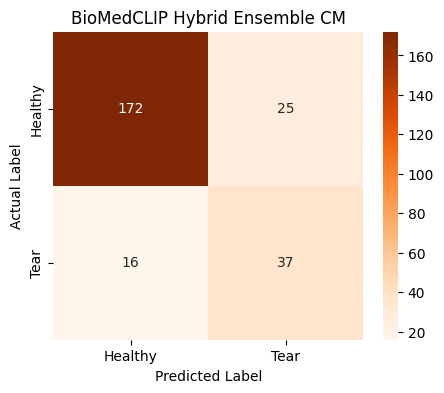

Visualizing Tear Patient index: 3


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.cuda.FloatTensor [2, 512]], which is output 0 of DivBackward0, is at version 1; expected version 0 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True).

In [ ]:



# ==========================================
# 5: EVALUATION (AVOIDING DATA LEAKAGE)
# ==========================================
hybrid_explain_dicts = {"axial": {}, "coronal": {}, "sagittal": {}}

def extract_hybrid_probabilities(plane_name, plane_dir, df, is_test=False):
    print(f"Extracting Hybrid features for {plane_name.upper()}...")

    model = HybridBioMedCLIP(clip_model, tokenizer).to(device)
    model.load_state_dict(torch.load(os.path.join(base_path, f"hybrid_{plane_name}_best.pth")))
    model.eval()

    dataset = HybridMRNetDataset(df, plane_dir, is_train=False)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    patient_probs, labels = [], []

    with torch.no_grad():
        for imgs, lbl, p_id in loader:
            imgs = imgs.squeeze(0).to(device)
            lbl = lbl.item()
            p_id = p_id[0]

            with autocast('cuda'):
                logits, attn_weights = model(imgs)

            prob_tear = logits.softmax(dim=-1)[0, 1].cpu().numpy()
            patient_probs.append(prob_tear)
            labels.append(lbl)

            if is_test:
                most_suspicious_idx = torch.argmax(attn_weights).item()
                hybrid_explain_dicts[plane_name][p_id] = most_suspicious_idx

    clip_model.visual = model.vision_encoder.unload()
    return np.array(patient_probs), np.array(labels)

# 1. Gather VAL probabilities to FIND Threshold
s_val_probs, y_val = extract_hybrid_probabilities("sagittal", sagittal_dir, val_df, is_test=False)
c_val_probs, _     = extract_hybrid_probabilities("coronal", coronal_dir, val_df, is_test=False)
a_val_probs, _     = extract_hybrid_probabilities("axial", axial_dir, val_df, is_test=False)

val_ensemble = (0.6 * s_val_probs) + (0.3 * c_val_probs) + (0.1 * a_val_probs)
fpr, tpr, thresholds = roc_curve(y_val, val_ensemble)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal decision threshold found on VAL set: {optimal_threshold:.4f}")

# 2. Gather TEST probabilities to APPLY Threshold
s_probs, y_true = extract_hybrid_probabilities("sagittal", sagittal_dir, test_df, is_test=True)
c_probs, _      = extract_hybrid_probabilities("coronal", coronal_dir, test_df, is_test=True)
a_probs, _      = extract_hybrid_probabilities("axial", axial_dir, test_df, is_test=True)

test_ensemble = (0.6 * s_probs) + (0.3 * c_probs) + (0.1 * a_probs)
final_preds = (test_ensemble >= optimal_threshold).astype(int)

# Metrics
print(f"\n{'='*50}\nTEST ENSEMBLE RESULTS\n{'='*50}")
print(f"Accuracy:           {accuracy_score(y_true, final_preds):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_true, final_preds):.4f}")
print(f"AUC:                {roc_auc_score(y_true, test_ensemble):.4f}")
print(f"Sensitivity:        {recall_score(y_true, final_preds):.4f} (Recall for Tears)")
tn, fp, fn, tp = confusion_matrix(y_true, final_preds).ravel()
print(f"Specificity:        {tn / (tn + fp) if (tn + fp) > 0 else 0:.4f} (Recall for Healthy)")
print(f"F1-Score:           {f1_score(y_true, final_preds):.4f}")

cm = confusion_matrix(y_true, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title("BioMedCLIP Hybrid Ensemble CM")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ==========================================
# 6: IMPROVED SALIENCY HEATMAPS
# ==========================================
def visualize_hybrid_explain(patient_idx=0, plane="sagittal"):
    patient_id = str(test_df.iloc[patient_idx]["id"]).zfill(4)
    true_label = test_df.iloc[patient_idx]["label"]
    target_idx = hybrid_explain_dicts[plane][patient_id]

    model = HybridBioMedCLIP(clip_model, tokenizer).to(device)
    model.load_state_dict(torch.load(os.path.join(base_path, f"hybrid_{plane}_best.pth")))
    model.eval()

    p_dir = sagittal_dir if plane=="sagittal" else (coronal_dir if plane=="coronal" else axial_dir)
    vol = np.load(os.path.join(p_dir, patient_id + ".npy"))
    ds = HybridMRNetDataset(test_df, p_dir, False)
    imgs_tensor, _, _ = ds[patient_idx]

    single_slice = imgs_tensor[target_idx:target_idx+1].clone().detach().to(device).requires_grad_(True)
    img_feat = model.vision_encoder(single_slice)
    img_feat /= img_feat.norm(dim=-1, keepdim=True)

    p_learner = model.prompt_learner()
    t_out = model.clip_model.text.transformer(inputs_embeds=p_learner, attention_mask=torch.ones((2,256), device=device))
    t_feat = model.clip_model.text.proj(t_out.last_hidden_state[:, 0, :])
    t_feat /= t_feat.norm(dim=-1, keepdim=True)

    score = (model.clip_model.logit_scale.exp() * img_feat @ t_feat[1:2].t()).squeeze()
    model.zero_grad()
    score.backward()

    saliency = single_slice.grad.data.abs().squeeze().cpu().numpy()
    saliency = np.maximum(saliency, 0)
    saliency = np.max(saliency, axis=0)

    saliency = cv2.GaussianBlur(saliency, (11, 11), 0)
    if saliency.max() != saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    else:
        saliency = np.zeros_like(saliency)

    heatmap = np.uint8(255 * saliency)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    vol_norm = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)
    slice_img_resized = cv2.resize(vol_norm[target_idx], (224, 224))
    slice_img_255 = (slice_img_resized * 255).astype(np.uint8)
    slice_rgb = np.stack((slice_img_255,)*3, axis=-1)

    overlay = cv2.addWeighted(slice_rgb, 0.5, heatmap_color, 0.5, 0)
    status = "TEAR" if true_label == 1 else "HEALTHY"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Patient {patient_id} (Actual: {status}) | Plane: {plane.capitalize()} | Gated Attention Top Slice #{target_idx}", fontsize=14)

    axes[0].imshow(slice_img_resized, cmap='gray'); axes[0].set_title("Original Slice"); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)); axes[1].set_title("Clean Saliency Map"); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[2].set_title("Overlay"); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    clip_model.visual = model.vision_encoder.unload()

tear_patients = test_df[test_df['label'] == 1].index.tolist()
if tear_patients:
    print(f"Visualizing Tear Patient index: {tear_patients[0]}")
    visualize_hybrid_explain(patient_idx=tear_patients[0], plane="sagittal")